# 04 — Production-Grade LightGBM
**TrustGraph Credit Risk Project**

Trains the tuned LightGBM model on the full engineered feature set from notebook 03,
evaluates with AUC-ROC, KS, Gini, and precision-recall, saves the model artifact and result charts.

In [1]:
import os
import pickle
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path
from matplotlib.patches import Patch

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score,
)
from scipy.stats import ks_2samp
import lightgbm as lgb

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 120
RANDOM_STATE = 42

ROOT       = Path(os.getcwd()).parent if Path(os.getcwd()).name == 'notebooks' else Path(os.getcwd())
DATA_PROC  = ROOT / 'data' / 'processed'
CHARTS_DIR = DATA_PROC / 'eda_charts'
MODELS_DIR = ROOT / 'models'

CHARTS_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

FEAT_FILE = DATA_PROC / 'features_train.csv'
if not FEAT_FILE.exists():
    raise FileNotFoundError(f"features_train.csv not found at {FEAT_FILE}. Run 03_features.ipynb first.")
print(f"Feature matrix: {FEAT_FILE}")

Feature matrix: C:\Users\krish\Downloads\TrustGraph\data\processed\features_train.csv


## 1. Load engineered feature matrix

In [2]:
df = pd.read_csv(FEAT_FILE)
print(f"Shape: {df.shape}")
print(f"Default rate: {df['TARGET'].mean():.3%}")

y = df['TARGET']
X = df.drop(columns=['TARGET', 'SK_ID_CURR'], errors='ignore')
print(f"Features: {X.shape[1]}")

Shape: (307511, 130)
Default rate: 8.073%
Features: 128


## 2. Train / validation split (80/20 stratified)

In [3]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)
print(f"Train: {X_train.shape}  |  Validation: {X_val.shape}")
print(f"Train default rate: {y_train.mean():.3%}  |  Val default rate: {y_val.mean():.3%}")

Train: (246008, 128)  |  Validation: (61503, 128)
Train default rate: 8.073%  |  Val default rate: 8.073%


## 3. Train production LightGBM with early stopping on validation AUC

In [4]:
model = lgb.LGBMClassifier(
    n_estimators=1000,
    learning_rate=0.03,
    num_leaves=63,
    min_child_samples=50,
    subsample=0.8,
    colsample_bytree=0.8,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=-1,
)

model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    eval_metric='auc',
    callbacks=[
        lgb.early_stopping(stopping_rounds=50, verbose=False),
        lgb.log_evaluation(period=100),
    ],
)

best_iter = model.best_iteration_
print(f"\nEarly stopping at tree: {best_iter} (patience=50)")

[100]	valid_0's auc: 0.75925	valid_0's binary_logloss: 0.57424


[200]	valid_0's auc: 0.767286	valid_0's binary_logloss: 0.552422


[300]	valid_0's auc: 0.769532	valid_0's binary_logloss: 0.538412


[400]	valid_0's auc: 0.770159	valid_0's binary_logloss: 0.52697


[500]	valid_0's auc: 0.770529	valid_0's binary_logloss: 0.516543



Early stopping at tree: 514 (patience=50)


## 4. Evaluate — AUC-ROC, KS statistic, Gini coefficient

In [5]:
prob = model.predict_proba(X_val)[:, 1]

auc   = roc_auc_score(y_val, prob)
gini  = 2 * auc - 1
ks, _ = ks_2samp(prob[y_val == 1], prob[y_val == 0])
ap    = average_precision_score(y_val, prob)   # area under PR curve

print(f"AUC-ROC : {auc:.4f}")
print(f"Gini    : {gini:.4f}")
print(f"KS      : {ks:.4f}")
print(f"Avg Prec: {ap:.4f}")
print(f"Best iter: {best_iter}")

AUC-ROC : 0.7707
Gini    : 0.5414
KS      : 0.4049
Avg Prec: 0.2597
Best iter: 514


## 5. Plots — ROC curve, Precision-Recall curve, Feature Importance

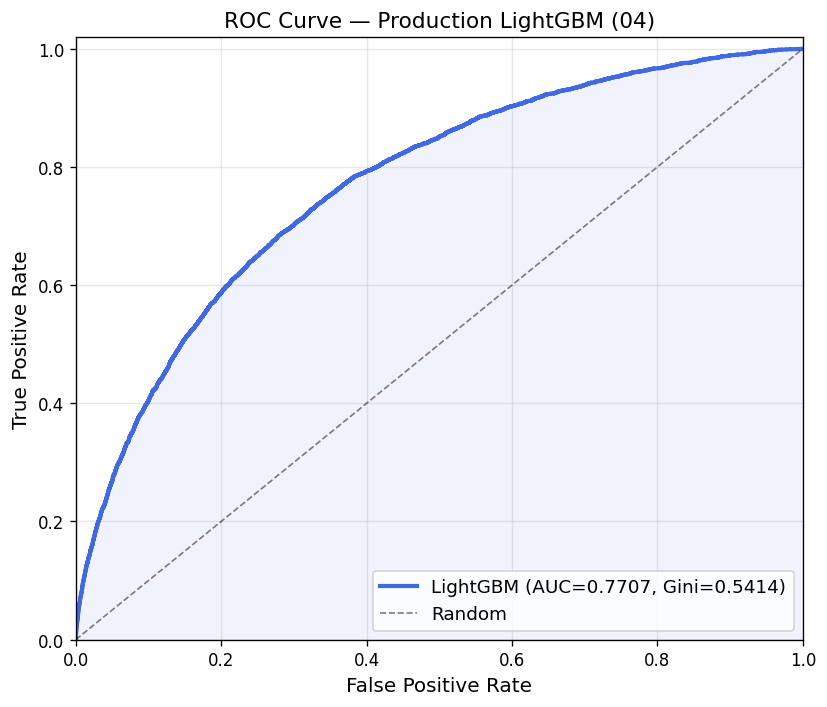

Saved: C:\Users\krish\Downloads\TrustGraph\data\processed\eda_charts\gbm_roc_curve.png


In [6]:
# ── ROC Curve ──────────────────────────────────────────────────────────────
fpr, tpr, _ = roc_curve(y_val, prob)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr, tpr, color='royalblue', lw=2.5,
        label=f'LightGBM (AUC={auc:.4f}, Gini={gini:.4f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5, label='Random')
ax.fill_between(fpr, tpr, alpha=0.08, color='royalblue')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curve — Production LightGBM (04)', fontsize=13)
ax.legend(loc='lower right', fontsize=11)
ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
ax.grid(True, alpha=0.3)
plt.tight_layout()
roc_path = CHARTS_DIR / 'gbm_roc_curve.png'
plt.savefig(roc_path, bbox_inches='tight')
plt.show()
print(f"Saved: {roc_path}")

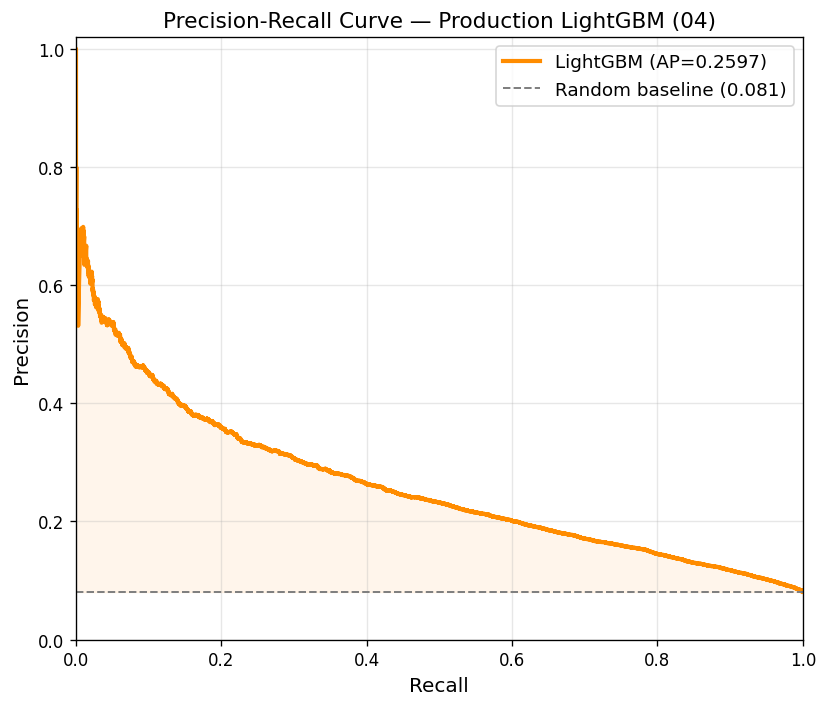

Saved: C:\Users\krish\Downloads\TrustGraph\data\processed\eda_charts\gbm_pr_curve.png


In [7]:
# ── Precision-Recall Curve ─────────────────────────────────────────────────
precision, recall, _ = precision_recall_curve(y_val, prob)
baseline_pr = y_val.mean()   # random classifier PR = class prevalence

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(recall, precision, color='darkorange', lw=2.5,
        label=f'LightGBM (AP={ap:.4f})')
ax.axhline(baseline_pr, color='grey', lw=1.2, linestyle='--',
           label=f'Random baseline ({baseline_pr:.3f})')
ax.fill_between(recall, precision, baseline_pr, alpha=0.08, color='darkorange')
ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Precision-Recall Curve — Production LightGBM (04)', fontsize=13)
ax.legend(loc='upper right', fontsize=11)
ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
ax.grid(True, alpha=0.3)
plt.tight_layout()
pr_path = CHARTS_DIR / 'gbm_pr_curve.png'
plt.savefig(pr_path, bbox_inches='tight')
plt.show()
print(f"Saved: {pr_path}")

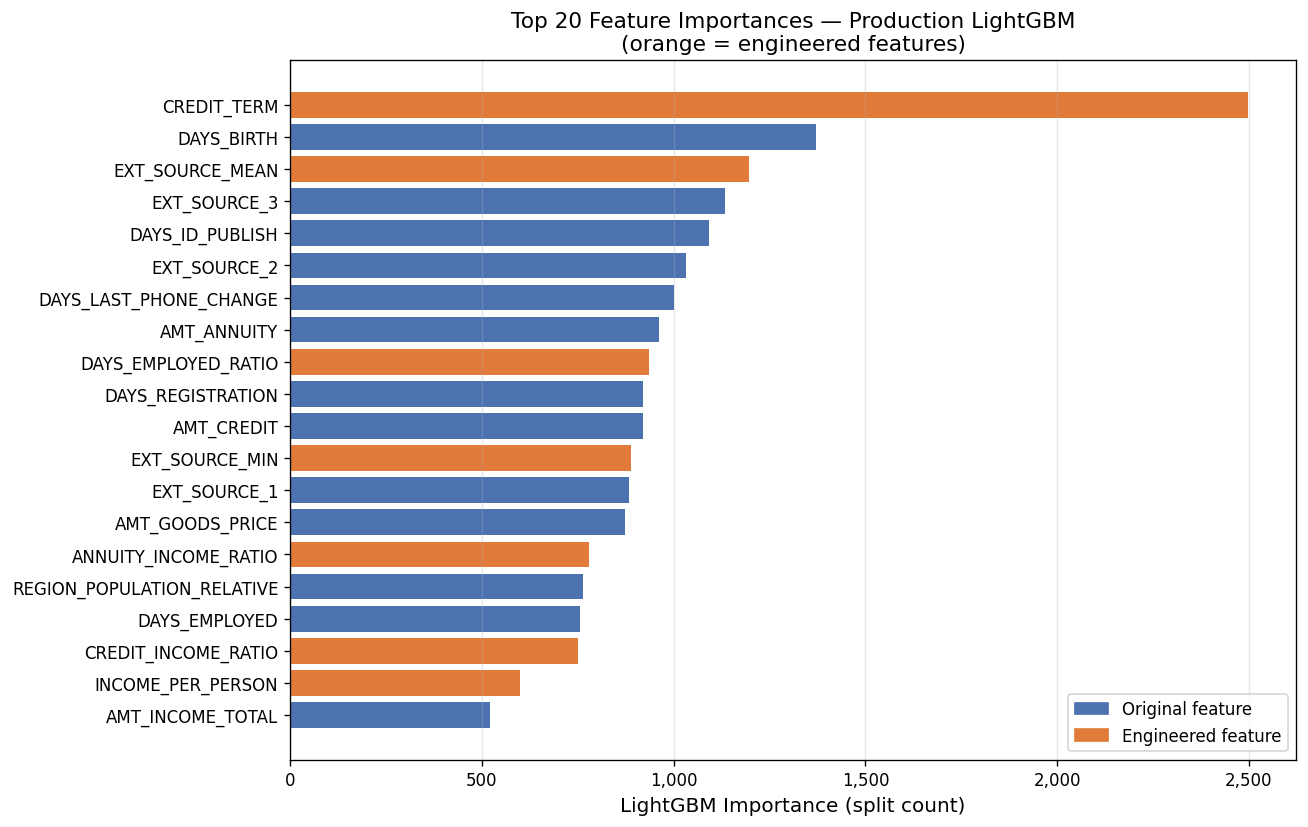

Saved: C:\Users\krish\Downloads\TrustGraph\data\processed\eda_charts\gbm_feature_importance.png

                   feature  importance  is_engineered
               CREDIT_TERM        2498           True
                DAYS_BIRTH        1372          False
           EXT_SOURCE_MEAN        1197           True
              EXT_SOURCE_3        1133          False
           DAYS_ID_PUBLISH        1091          False
              EXT_SOURCE_2        1031          False
    DAYS_LAST_PHONE_CHANGE        1001          False
               AMT_ANNUITY         963          False
       DAYS_EMPLOYED_RATIO         936           True
         DAYS_REGISTRATION         920          False
                AMT_CREDIT         919          False
            EXT_SOURCE_MIN         888           True
              EXT_SOURCE_1         883          False
           AMT_GOODS_PRICE         873          False
      ANNUITY_INCOME_RATIO         778           True
REGION_POPULATION_RELATIVE         764 

In [8]:
# ── Feature Importance — top 20 ────────────────────────────────────────────
engineered = [
    'CREDIT_INCOME_RATIO', 'ANNUITY_INCOME_RATIO', 'CREDIT_TERM',
    'DAYS_EMPLOYED_RATIO', 'EXT_SOURCE_MEAN', 'EXT_SOURCE_MIN',
    'INCOME_PER_PERSON', 'FLAG_MISSING_EXT',
]

importance = (
    pd.DataFrame({'feature': X_train.columns, 'importance': model.feature_importances_})
    .sort_values('importance', ascending=False)
    .head(20)
)
importance['is_engineered'] = importance['feature'].isin(engineered)
colors = ['#e07b39' if e else '#4c72b0' for e in importance['is_engineered']]

fig, ax = plt.subplots(figsize=(11, 7))
ax.barh(importance['feature'][::-1], importance['importance'][::-1], color=colors[::-1])
ax.set_xlabel('LightGBM Importance (split count)', fontsize=12)
ax.set_title('Top 20 Feature Importances — Production LightGBM\n(orange = engineered features)', fontsize=13)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.grid(axis='x', alpha=0.3)
ax.legend(handles=[
    Patch(color='#4c72b0', label='Original feature'),
    Patch(color='#e07b39', label='Engineered feature'),
], loc='lower right', fontsize=10)
plt.tight_layout()
imp_path = CHARTS_DIR / 'gbm_feature_importance.png'
plt.savefig(imp_path, bbox_inches='tight')
plt.show()
print(f"Saved: {imp_path}")
print()
print(importance[['feature','importance','is_engineered']].to_string(index=False))

## 6. Save trained model

In [9]:
model_path = MODELS_DIR / 'lgbm_final.pkl'
with open(model_path, 'wb') as f:
    pickle.dump(model, f)
size_mb = model_path.stat().st_size / 1e6
print(f"Model saved: {model_path}  ({size_mb:.2f} MB)")

Model saved: C:\Users\krish\Downloads\TrustGraph\models\lgbm_final.pkl  (3.64 MB)


## 7. Save results and print final summary

In [10]:
results = pd.DataFrame([{
    'Model':         'LightGBM Production (04)',
    'AUC_ROC':       round(auc,  4),
    'Gini':          round(gini, 4),
    'KS_Statistic':  round(ks,   4),
    'Avg_Precision': round(ap,   4),
    'Best_Iteration': best_iter,
    'n_estimators':  1000,
    'learning_rate': 0.03,
    'num_leaves':    63,
}])

gbm_path = DATA_PROC / 'gbm_results.csv'
results.to_csv(gbm_path, index=False)
print(f"Saved: {gbm_path}")
results

Saved: C:\Users\krish\Downloads\TrustGraph\data\processed\gbm_results.csv


,Model,AUC_ROC,Gini,KS_Statistic,Avg_Precision,Best_Iteration,n_estimators,learning_rate,num_leaves
0,LightGBM Production (04),0.7707,0.5414,0.4049,0.2597,514,1000,0.03,63


In [11]:
# Load notebook-03 baseline for delta comparison
feat_res_path = DATA_PROC / 'feature_results.csv'
if feat_res_path.exists():
    prev = pd.read_csv(feat_res_path)
    prev_row = prev[prev['Model'].str.contains('Engineered')].iloc[0]
    prev_auc = prev_row['AUC_ROC']
    prev_ks  = prev_row['KS_Statistic']
else:
    prev_auc, prev_ks = 0.7689, 0.4032   # notebook-03 numbers

print("=" * 54)
print("  PRODUCTION GBM — FINAL RESULTS")
print("=" * 54)
print(f"  AUC-ROC       : {auc:.4f}  (prev {prev_auc:.4f}, delta {auc-prev_auc:+.4f})")
print(f"  Gini          : {gini:.4f}")
print(f"  KS Statistic  : {ks:.4f}  (prev {prev_ks:.4f}, delta {ks-prev_ks:+.4f})")
print(f"  Avg Precision : {ap:.4f}")
print(f"  Early stopped : tree {best_iter} / 1000")
print("=" * 54)
print()
print("Artifacts:")
print("  models/lgbm_final.pkl")
print("  data/processed/gbm_results.csv")
print("  data/processed/eda_charts/gbm_roc_curve.png")
print("  data/processed/eda_charts/gbm_pr_curve.png")
print("  data/processed/eda_charts/gbm_feature_importance.png")

  PRODUCTION GBM — FINAL RESULTS
  AUC-ROC       : 0.7707  (prev 0.7689, delta +0.0018)
  Gini          : 0.5414
  KS Statistic  : 0.4049  (prev 0.4032, delta +0.0017)
  Avg Precision : 0.2597
  Early stopped : tree 514 / 1000

Artifacts:
  models/lgbm_final.pkl
  data/processed/gbm_results.csv
  data/processed/eda_charts/gbm_roc_curve.png
  data/processed/eda_charts/gbm_pr_curve.png
  data/processed/eda_charts/gbm_feature_importance.png
